# Algorithmic Analysis: CNN vs Fully-Connected Neural Networks
## Performance Comparison on MNIST and High-Resolution Image Classification

### Project Metadata
- **Institution**: Imam Abdulrahman Bin Faisal University
- **Course**: CS412 - Algorithms Analysis and Design
- **Term**: 1 (2024-2025)
- **Objective**: Compare CNN and NN algorithms on MNIST and 240px dataset

## 1. Configuration & Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torchvision import datasets
import time
import warnings
import kagglehub
import os
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

CONFIG = {
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'batch_size': 64,
    'num_epochs': 10,
    'learning_rate': 0.001,
    'mnist_size': 28,
    'high_res_size': 256,
}

print(f'Device: {CONFIG["device"]}')
print(f'CUDA Available: {torch.cuda.is_available()}')

Device: cuda
CUDA Available: True


## 2. CNN Model Implementation

In [ ]:
class SimpleCNN(nn.Module):
    """
    Efficient CNN for image classification.
    Complexity: O(N * H * W * K^2 * Cin * Cout)
    """
    def __init__(self, in_channels=1, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU(inplace=True)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.pool3(x)

        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

print('SimpleCNN defined successfully')

SimpleCNN defined successfully


## 3. Fully-Connected NN Model Implementation

In [ ]:
class FullyConnectedNN(nn.Module):
    """
    Fully-connected neural network for image classification.
    Complexity: O(N * Din * Dout) where Din = H*W*C (flattened)
    """
    def __init__(self, input_size, num_classes=10, hidden_sizes=None):
        super(FullyConnectedNN, self).__init__()
        self.input_size = input_size
        self.num_classes = num_classes

        if hidden_sizes is None:
            hidden_sizes = [512, 256, 128]

        layers = []
        prev_size = input_size

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU(inplace=True))
            layers.append(nn.Dropout(0.5))
            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)

print('FullyConnectedNN defined successfully')

FullyConnectedNN defined successfully


## 4. Parameter Counting & Complexity Analysis

In [ ]:
def count_parameters(model):
    """Count trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
def calculate_average(number_list):
    """Calculates the average of a list of numbers."""
    if not number_list:  # Handle empty list case to avoid division by zero
        return 0

    total_sum = sum(number_list)  # Sums all elements in the list
    count = len(number_list)      # Gets the number of elements in the list
    average = total_sum / count
    return average

In [ ]:
print('Defining FLOPs calculation function and average calculation function. (These functions are already defined in the previous step, but re-printing for context)')

def calculate_flops(model, input_size):
    """
    Calculates the Floating Point Operations (FLOPs) for a PyTorch model.
    Accounts for Conv2d, Linear, BatchNorm2d, MaxPool2d, and ReLU.
    Approximations used:
    - Conv2d: 2 * Cin * K*K * H_out * W_out * Cout (multiply-adds)
    - Linear: 2 * In_features * Out_features (multiply-adds)
    - BatchNorm2d: 2 * C * H * W (multiply-adds)
    - MaxPool2d: 0 (typically considered negligible)
    - ReLU: 0 (typically considered negligible, comparison operation)
    """
    flops = 0
    # Create a dummy input tensor
    input_tensor = torch.randn(1, *input_size).to(next(model.parameters()).device)

    # Store original forward hooks to restore them later
    original_forward_hooks = {}
    for name, module in model.named_modules():
        if hasattr(module, '_forward_hooks'):
            original_forward_hooks[name] = list(module._forward_hooks.values())
            module._forward_hooks.clear() # Clear existing hooks to avoid double counting or interference

    def hook(module, input, output):
        nonlocal flops
        if isinstance(module, nn.Conv2d):
            Cin, H_in, W_in = input[0].shape[1:]
            Cout, H_out, W_out = output.shape[1:]
            kernel_size = module.kernel_size[0]

            flops += 2 * Cin * kernel_size * kernel_size * Cout * H_out * W_out
            if module.bias is not None:
                flops += Cout * H_out * W_out

        elif isinstance(module, nn.Linear):
            In_features = input[0].shape[1]
            Out_features = output.shape[1]
            flops += 2 * In_features * Out_features
            if module.bias is not None:
                flops += Out_features

        elif isinstance(module, nn.BatchNorm2d):
            C, H, W = input[0].shape[1:]
            flops += 4 * C * H * W

        elif isinstance(module, (nn.MaxPool2d, nn.ReLU, nn.AdaptiveAvgPool2d, nn.Dropout)):
            pass

    handles = []
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.Linear, nn.BatchNorm2d, nn.MaxPool2d, nn.ReLU, nn.AdaptiveAvgPool2d, nn.Dropout)):
            handles.append(m.register_forward_hook(hook))

    # Perform a forward pass to trigger the hooks
    with torch.no_grad():
        model(input_tensor)

    for h in handles:
        h.remove()

    # Restore original forward hooks
    for name, module in model.named_modules():
        if name in original_forward_hooks:
            for original_hook in original_forward_hooks[name]:
                module.register_forward_hook(original_hook)

    return flops

def calculate_average(data_list):
    """Calculates the average of a list of numbers."""
    if not data_list:
        return 0
    return sum(data_list) / len(data_list)

print("FLOPs calculation function and average calculation function defined.")

Defining FLOPs calculation function and average calculation function. (These functions are already defined in the previous step, but re-printing for context)
FLOPs calculation function and average calculation function defined.


## 5. Dataset Loading

In [ ]:
# MNIST Dataset
print('Loading MNIST...')
transform_mnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

mnist_train = datasets.MNIST('./data', train=True, download=True, transform=transform_mnist)
mnist_test = datasets.MNIST('./data', train=False, download=True, transform=transform_mnist)

mnist_train = torch.utils.data.Subset(mnist_train, range(10000))
mnist_test = torch.utils.data.Subset(mnist_test, range(2000))

mnist_train_loader = DataLoader(mnist_train, batch_size=CONFIG['batch_size'], shuffle=True)
mnist_test_loader = DataLoader(mnist_test, batch_size=CONFIG['batch_size'], shuffle=False)

print(f'MNIST Train: {len(mnist_train)} samples')
print(f'MNIST Test: {len(mnist_test)} samples')

Loading MNIST...


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.60MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.94MB/s]

MNIST Train: 10000 samples
MNIST Test: 2000 samples


## 6. Training Function with Measurements

In [ ]:
def train_model(model, train_loader, test_loader, num_epochs, device, model_name):
    """Train model and measure performance."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])
    model.to(device)

    results = {
        'model': model_name,
        'train_times': [],
        'test_accuracies': [],
    }

    print(f'Training {model_name}...')
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        start_time = time.time()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        epoch_time = (time.time() - start_time) * 1000
        results['train_times'].append(epoch_time)

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        results['test_accuracies'].append(accuracy)

        if (epoch + 1) % 2 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}] - Acc: {accuracy:.2f}%, Time: {epoch_time:.2f}ms')

    return model, results

print('Training function defined')

Training function defined


## 7. MNIST Experiments

In [ ]:
print('\n=== MNIST Experiments ===')

cnn_mnist = SimpleCNN(in_channels=1, num_classes=10)
fc_nn_mnist = FullyConnectedNN(input_size=28*28*1, num_classes=10)

cnn_params = count_parameters(cnn_mnist)
fc_params = count_parameters(fc_nn_mnist)

print(f'CNN Parameters: {cnn_params:,}')
print(f'FC-NN Parameters: {fc_params:,}')
print(f'Ratio (FC/CNN): {fc_params/cnn_params:.2f}x')

cnn_mnist, cnn_results = train_model(
    cnn_mnist, mnist_train_loader, mnist_test_loader,
    num_epochs=CONFIG['num_epochs'], device=CONFIG['device'], model_name='CNN (MNIST)'
)

fc_nn_mnist, fc_results = train_model(
    fc_nn_mnist, mnist_train_loader, mnist_test_loader,
    num_epochs=CONFIG['num_epochs'], device=CONFIG['device'], model_name='FC-NN (MNIST)'
)


=== MNIST Experiments ===
CNN Parameters: 102,026
FC-NN Parameters: 567,434
Ratio (FC/CNN): 5.56x
Training CNN (MNIST)...
Epoch [2/10] - Acc: 96.15%, Time: 2447.19ms
Epoch [4/10] - Acc: 90.15%, Time: 2468.07ms
Epoch [6/10] - Acc: 96.65%, Time: 2463.33ms
Epoch [8/10] - Acc: 93.45%, Time: 2495.61ms
Epoch [10/10] - Acc: 95.10%, Time: 2512.40ms
Training FC-NN (MNIST)...
Epoch [2/10] - Acc: 91.05%, Time: 2146.19ms
Epoch [4/10] - Acc: 92.70%, Time: 2089.34ms
Epoch [6/10] - Acc: 93.25%, Time: 2279.73ms
Epoch [8/10] - Acc: 93.95%, Time: 2168.57ms
Epoch [10/10] - Acc: 94.40%, Time: 2767.97ms


## 8. Results Comparison - MNIST

In [ ]:
results_mnist = pd.DataFrame({
    'Metric': [
        'Parameters',
        'Avg Epoch Time (ms)',
        'Final Accuracy (%)',
    ],
    'CNN': [
        f"{cnn_params:,}",
        f"{np.mean(cnn_results['train_times']):.2f}",
        f"{cnn_results['test_accuracies'][-1]:.2f}",
    ],
    'FC-NN': [
        f"{fc_params:,}",
        f"{np.mean(fc_results['train_times']):.2f}",
        f"{fc_results['test_accuracies'][-1]:.2f}",
    ],
})

print('\nMNIST Results Comparison')
print(results_mnist.to_string(index=False))
results_mnist.to_csv('mnist_comparison.csv', index=False)
print('\nSaved to: mnist_comparison.csv')


MNIST Results Comparison
             Metric     CNN   FC-NN
         Parameters 102,026 567,434
Avg Epoch Time (ms) 2706.35 2316.75
 Final Accuracy (%)   95.10   94.40

Saved to: mnist_comparison.csv


##Tomato leaf disease detection Dataset

In [ ]:
# Download latest version
path = kagglehub.dataset_download("kaustubhb999/tomatoleaf")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tomatoleaf' dataset.
Path to dataset files: /kaggle/input/tomatoleaf


In [ ]:
# List the contents of the downloaded Kaggle dataset directory recursively
!ls -R {path}

Streaming output truncated to the last 5000 lines.
'129160ba-d6f0-434c-b399-735d61a39a16___Com.G_SpM_FL 8628.JPG'
'1384ca63-9181-4245-b7ab-7a1f0fec34a8___Com.G_SpM_FL 9269.JPG'
'140136da-2b1c-4a29-b984-31e693c10d1c___Com.G_SpM_FL 9442.JPG'
'1425cd68-8978-4811-b591-5154974458d2___Com.G_SpM_FL 8435.JPG'
'1513f896-fb53-4f0f-9b11-a31a01196221___Com.G_SpM_FL 8995.JPG'
'16826b8c-034f-4db2-bd96-db82b5b26c67___Com.G_SpM_FL 1551.JPG'
'1687e54f-583f-4ecb-9b63-c36ea438baba___Com.G_SpM_FL 9577.JPG'
'1744606c-1817-494d-bb7c-6ea74c9f07ec___Com.G_SpM_FL 8770.JPG'
'1747e771-a2c7-43e0-a158-02a78ec13d74___Com.G_SpM_FL 9625.JPG'
'1767a6b2-2764-49a1-b774-3c411337bb63___Com.G_SpM_FL 1201.JPG'
'185427fc-b158-483e-8bbf-3579fc49c8dc___Com.G_SpM_FL 1428.JPG'
'18663563-6c5e-43f0-bed8-72e7c9adc3ee___Com.G_SpM_FL 8831.JPG'
'1948cb2f-39fc-44f4-ab8c-00aa77fbe07f___Com.G_SpM_FL 8674.JPG'
'1954b3c0-6f93-40ee-9618-4efafe5d7b87___Com.G_SpM_FL 8961.JPG'
'200410b0-390d-406f-aa66-5573ec4d8e04___Com.G_SpM_FL 1214.JPG'
'202

In [ ]:
# 1. Define transformations for the Tomato Leaf dataset
print('Defining transformations for Tomato Leaf dataset...')
transform_high_res = transforms.Compose([
    transforms.Resize((CONFIG['high_res_size'], CONFIG['high_res_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # Normalization for RGB images
])

# 2. Load the Tomato Leaf dataset directly from train and val subdirectories
# Assuming the structure is: path/tomato/train/... and path/tomato/val/...

train_data_dir = os.path.join(path, 'tomato', 'train')
test_data_dir = os.path.join(path, 'tomato', 'val')

print(f'Loading Tomato Leaf training dataset from: {train_data_dir}')
train_dataset = ImageFolder(train_data_dir, transform=transform_high_res)

print(f'Loading Tomato Leaf testing dataset from: {test_data_dir}')
test_dataset = ImageFolder(test_data_dir, transform=transform_high_res)

print(f'Tomato Leaf Train: {len(train_dataset)} samples')
print(f'Tomato Leaf Test: {len(test_dataset)} samples')

# 3. Create DataLoader instances
tomato_train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
tomato_test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

# 4. Determine the number of classes and input channels
num_classes_tomato = len(train_dataset.classes)
in_channels_tomato = 3 # RGB images

print(f'Number of classes in Tomato Leaf dataset: {num_classes_tomato}')
print(f'Input channels for Tomato Leaf dataset: {in_channels_tomato}')

Defining transformations for Tomato Leaf dataset...
Loading Tomato Leaf training dataset from: /kaggle/input/tomatoleaf/tomato/train
Loading Tomato Leaf testing dataset from: /kaggle/input/tomatoleaf/tomato/val
Tomato Leaf Train: 10000 samples
Tomato Leaf Test: 1000 samples
Number of classes in Tomato Leaf dataset: 10
Input channels for Tomato Leaf dataset: 3


In [ ]:
print('\n=== Tomato Leaf Experiments ===')

# 1. Create an instance of the SimpleCNN model
cnn_tomato = SimpleCNN(in_channels=in_channels_tomato, num_classes=num_classes_tomato)

# 2. Calculate the input_size for the FullyConnectedNN
input_size_fc_tomato = CONFIG['high_res_size'] * CONFIG['high_res_size'] * in_channels_tomato

# 3. Create an instance of the FullyConnectedNN model
fc_nn_tomato = FullyConnectedNN(input_size=input_size_fc_tomato, num_classes=num_classes_tomato)

# 4. Print a confirmation message
print('SimpleCNN and FullyConnectedNN models for Tomato Leaf dataset instantiated successfully.')


=== Tomato Leaf Experiments ===
SimpleCNN and FullyConnectedNN models for Tomato Leaf dataset instantiated successfully.


In [ ]:
cnn_tomato_params = count_parameters(cnn_tomato)
fc_nn_tomato_params = count_parameters(fc_nn_tomato)

print(f'CNN Parameters (Tomato): {cnn_tomato_params:,}')
print(f'FC-NN Parameters (Tomato): {fc_nn_tomato_params:,}')
print(f'Ratio (FC/CNN) (Tomato): {fc_nn_tomato_params/cnn_tomato_params:.2f}x')

CNN Parameters (Tomato): 102,602
FC-NN Parameters (Tomato): 100,829,322
Ratio (FC/CNN) (Tomato): 982.72x


In [ ]:
print('\nTraining CNN on Tomato Leaf dataset...')
cnn_tomato, cnn_tomato_results = train_model(
    cnn_tomato, tomato_train_loader, tomato_test_loader,
    num_epochs=6, device=CONFIG['device'], model_name='CNN (Tomato)'
)

print('\nTraining FC-NN on Tomato Leaf dataset...')
fc_nn_tomato, fc_nn_tomato_results = train_model(
    fc_nn_tomato, tomato_train_loader, tomato_test_loader,
    num_epochs=6, device=CONFIG['device'], model_name='FC-NN (Tomato)'
)


Training CNN on Tomato Leaf dataset...
Training CNN (Tomato)...
Epoch [2/6] - Acc: 79.50%, Time: 57385.96ms
Epoch [4/6] - Acc: 76.20%, Time: 54957.49ms
Epoch [6/6] - Acc: 89.10%, Time: 55671.76ms

Training FC-NN on Tomato Leaf dataset...
Training FC-NN (Tomato)...
Epoch [2/6] - Acc: 41.80%, Time: 37075.62ms
Epoch [4/6] - Acc: 55.80%, Time: 36407.69ms
Epoch [6/6] - Acc: 60.00%, Time: 37793.65ms


In [ ]:
print(f"This is the average Training time for CNN --> {calculate_average(cnn_tomato_results["train_times"])}")
print(f"This is the average Training time for FCNN --> {calculate_average(fc_nn_tomato_results["train_times"])}")
print("-" * 50)
print(f"The accuracy of CNN model --> {cnn_tomato_results["test_accuracies"][-1]}")
print(f"The accuracy of CNN model --> {fc_nn_tomato_results["test_accuracies"][-1]}")

This is the average Training time for CNN --> 63874.20014540354
This is the average Training time for FCNN --> 36979.33042049408
--------------------------------------------------
The accuracy of CNN model --> 89.1
The accuracy of CNN model --> 60.0


## 10. Conclusions

In [ ]:
data = {
    'Dataset': ['MNIST', 'MNIST', 'Tomato Leaf', 'Tomato Leaf'],
    'Model': ['CNN', 'FC-NN', 'CNN', 'FC-NN'],
    'Parameters': [
        cnn_params, fc_params,
        cnn_tomato_params, fc_nn_tomato_params
    ],
    'FLOPs': [
        cnn_mnist_flops, fc_nn_mnist_flops,
        cnn_tomato_flops, fc_nn_tomato_flops
    ],
    'Accuracy': [
        cnn_results['test_accuracies'][-1], fc_results['test_accuracies'][-1],
        cnn_tomato_results['test_accuracies'][-1], fc_nn_tomato_results['test_accuracies'][-1]
    ],
    'Avg_Train_Time_ms': [
        calculate_average(cnn_results['train_times']), calculate_average(fc_results['train_times']),
        calculate_average(cnn_tomato_results['train_times']), calculate_average(fc_nn_tomato_results['train_times'])
    ]
}

metrics_df_wide = pd.DataFrame(data)

metrics_df_long = pd.melt(metrics_df_wide, id_vars=['Dataset', 'Model'],
                          var_name='Metric', value_name='Value')

print('Consolidated Metrics DataFrame (Wide Format):')
print(metrics_df_wide.to_string(index=False))

# Temporarily set display options to prevent scientific notation and format floats
original_float_format = pd.get_option('display.float_format') # Store original setting
pd.set_option('display.float_format', '{:,.2f}'.format)

print('\nConsolidated Metrics DataFrame (Long Format for plotting):')
print(metrics_df_long.to_string(index=False))

# Reset to original float format after printing
pd.set_option('display.float_format', original_float_format)

metrics_df_long.to_csv('model_performance_metrics.csv', index=False)
print("\nSaved consolidated metrics to 'model_performance_metrics.csv'")

Consolidated Metrics DataFrame (Wide Format):
    Dataset Model  Parameters      FLOPs  Accuracy  Avg_Train_Time_ms
      MNIST   CNN      102026   15139530      95.1        2706.353903
      MNIST FC-NN      567434    1133962      94.4        2316.752768
Tomato Leaf   CNN      102602 1339573578      89.1       63874.200145
Tomato Leaf FC-NN   100829322  201657738      60.0       36979.330420

Consolidated Metrics DataFrame (Long Format for plotting):
    Dataset Model            Metric            Value
      MNIST   CNN        Parameters       102,026.00
      MNIST FC-NN        Parameters       567,434.00
Tomato Leaf   CNN        Parameters       102,602.00
Tomato Leaf FC-NN        Parameters   100,829,322.00
      MNIST   CNN             FLOPs    15,139,530.00
      MNIST FC-NN             FLOPs     1,133,962.00
Tomato Leaf   CNN             FLOPs 1,339,573,578.00
Tomato Leaf FC-NN             FLOPs   201,657,738.00
      MNIST   CNN          Accuracy            95.10
      MNIST FC

In [ ]:
print(f"The number of FLOPs in FC-NN has increased {flops_data['FLOPs'][3] / flops_data['FLOPs'][1]:.2f}x")
print(f"The number of FLOPs in FC-NN has increased {flops_data['FLOPs'][2] / flops_data['FLOPs'][0]:.2f}x")
print(f"\nThis shows that despite the high number of FLOPs in CNN but the increase is even greater in sime FC-NN \nso even with higher and higher resolution in images the FC-NN will be greater then the FLOPs in CNN")

The number of FLOPs in FC-NN has increased 177.83x
The number of FLOPs in FC-NN has increased 88.48x

This shows that despite the high number of FLOPs in CNN but the increase is even greater in sime FC-NN 
so even with higher and higher resolution in images the FC-NN will be greater then the FLOPs in CNN


In [ ]:
cnn_tomato_params = count_parameters(cnn_tomato)
fc_nn_tomato_params = count_parameters(fc_nn_tomato)

print(f'CNN Parameters (Tomato): {cnn_tomato_params:,}')
print(f'FC-NN Parameters (Tomato): {fc_nn_tomato_params:,}')
print(f'Ratio (FC/CNN) (Tomato): {fc_nn_tomato_params/cnn_tomato_params:.2f}x')

print(f'\nCNN Parameters: {cnn_params:,}')
print(f'FC-NN Parameters: {fc_params:,}')
print(f'Ratio (FC/CNN): {fc_params/cnn_params:.2f}x')

CNN Parameters (Tomato): 102,602
FC-NN Parameters (Tomato): 100,829,322
Ratio (FC/CNN) (Tomato): 982.72x

CNN Parameters: 102,026
FC-NN Parameters: 567,434
Ratio (FC/CNN): 5.56x


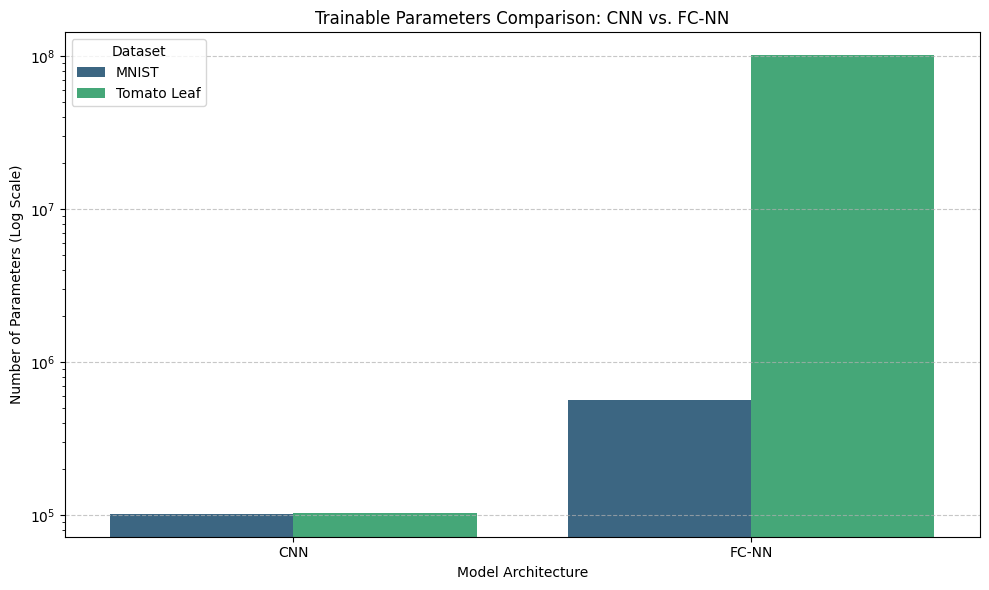

In [ ]:
# Filter the DataFrame for 'Parameters' metric
parameters_df = metrics_df_long[metrics_df_long['Metric'] == 'Parameters']

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=parameters_df, x='Model', y='Value', hue='Dataset', palette='viridis')

# Set title and labels
plt.title('Trainable Parameters Comparison: CNN vs. FC-NN')
plt.xlabel('Model Architecture')
plt.ylabel('Number of Parameters (Log Scale)')
plt.yscale('log') # Apply logarithmic scale to the y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Dataset')

# Display the plot
plt.tight_layout()
plt.show()

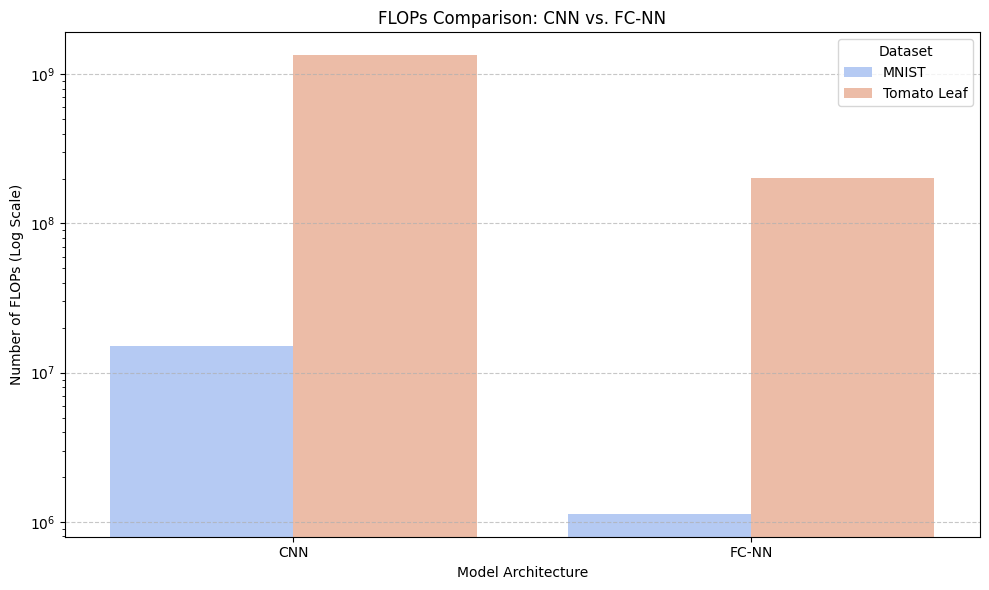

In [ ]:
# Filter the DataFrame for 'FLOPs' metric
flops_df_plot = metrics_df_long[metrics_df_long['Metric'] == 'FLOPs']

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=flops_df_plot, x='Model', y='Value', hue='Dataset', palette='coolwarm')

# Set title and labels
plt.title('FLOPs Comparison: CNN vs. FC-NN')
plt.xlabel('Model Architecture')
plt.ylabel('Number of FLOPs (Log Scale)')
plt.yscale('log') # Apply logarithmic scale to the y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Dataset')

# Display the plot
plt.tight_layout()
plt.show()

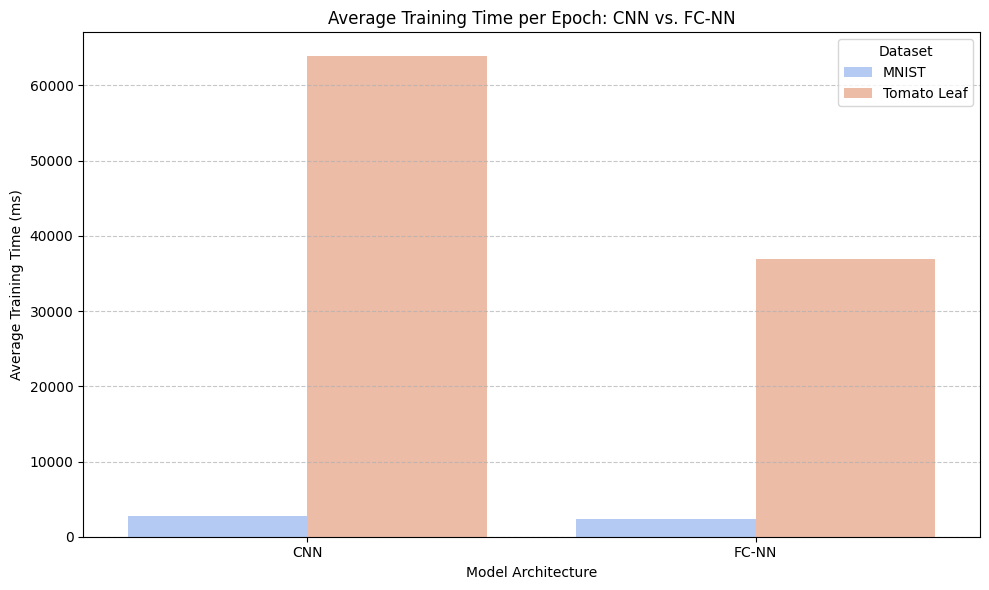

In [ ]:
# Filter the DataFrame for 'Avg_Train_Time_ms' metric
training_time_df_plot = metrics_df_long[metrics_df_long['Metric'] == 'Avg_Train_Time_ms']

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=training_time_df_plot, x='Model', y='Value', hue='Dataset', palette='coolwarm')

# Set title and labels
plt.title('Average Training Time per Epoch: CNN vs. FC-NN')
plt.xlabel('Model Architecture')
plt.ylabel('Average Training Time (ms)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Dataset')

# Display the plot
plt.tight_layout()
plt.show()